### 1. Import necessary libraries

We'll use `tensorflow` for building the RNN model and `numpy` for generating some dummy sequential data.

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, LSTM
import numpy as np
import matplotlib.pyplot as plt

### 2. Generate dummy sequential data

For a simple demonstration, let's create a dataset where the output is a simple function of the input sequence. We'll generate a sine wave sequence.

Shape of X: (1000, 10, 1)
Shape of y: (1000,)


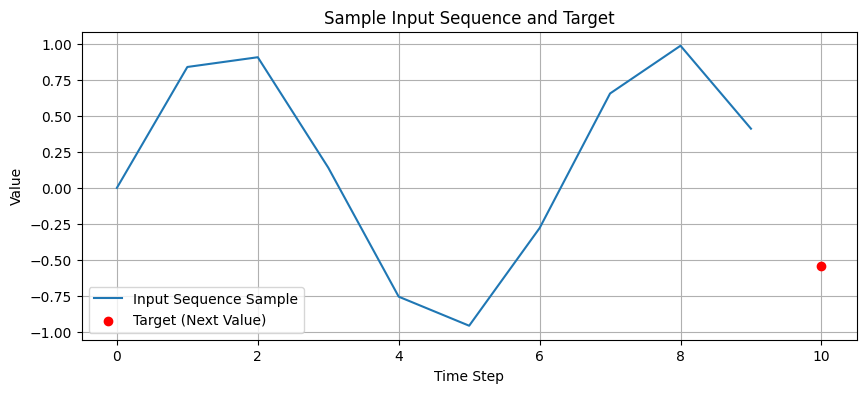

In [2]:
# Define sequence parameters
seq_length = 10
num_samples = 1000

# Generate input sequences (e.g., sine wave samples)
X = np.array([np.sin(i + np.arange(seq_length)) for i in np.linspace(0, 100, num_samples)])

# For a simple task, let's say the target is the next value in the sequence
y = np.array([np.sin(i + seq_length) for i in np.linspace(0, 100, num_samples)])

# Reshape X for RNN input: (num_samples, seq_length, num_features)
# Here, each element in the sequence is a single feature.
X = X.reshape(num_samples, seq_length, 1)

# Reshape y for output: (num_samples,)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Visualize a sample sequence
plt.figure(figsize=(10, 4))
plt.plot(X[0, :, 0], label='Input Sequence Sample')
plt.scatter(seq_length, y[0], color='red', zorder=5, label='Target (Next Value)')
plt.title('Sample Input Sequence and Target')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### 3. Define the RNN model

We'll create a simple RNN with one `SimpleRNN` layer followed by a `Dense` output layer. The `input_shape` for the `SimpleRNN` layer should be `(seq_length, num_features)`.

In [10]:
model = Sequential([
    Input(shape=(seq_length, 1)), # Explicit Input layer to avoid UserWarning
    LSTM(units=32, activation='relu'),
    Dense(units=1) # Output a single value
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Compile the model

We need to specify an optimizer, a loss function, and metrics. For regression tasks (predicting a continuous value), 'mse' (Mean Squared Error) is a common choice for the loss function.

In [4]:
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # MAE: Mean Absolute Error

### 5. Train the model

Now, let's train the model using our generated data. We'll use a validation split to monitor performance on unseen data during training.

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.4402 - mae: 0.5887 - val_loss: 0.2800 - val_mae: 0.4707
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2049 - mae: 0.3941 - val_loss: 0.1001 - val_mae: 0.2500
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0455 - mae: 0.1500 - val_loss: 0.0096 - val_mae: 0.0811
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 - mae: 0.0548 - val_loss: 0.0017 - val_mae: 0.0339
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.9416e-04 - mae: 0.0259 - val_loss: 5.0874e-04 - val_mae: 0.0187
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3358e-04 - mae: 0.0152 - val_loss: 2.3253e-04 - val_mae: 0.0129
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8595e-04 - mae: 0.0115 - val_loss: 1.4986e-04 - val_mae: 0.0101
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3784e-04 - mae: 0.0096 - val_loss: 1.0784e-04 - val_mae: 0.0085
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0

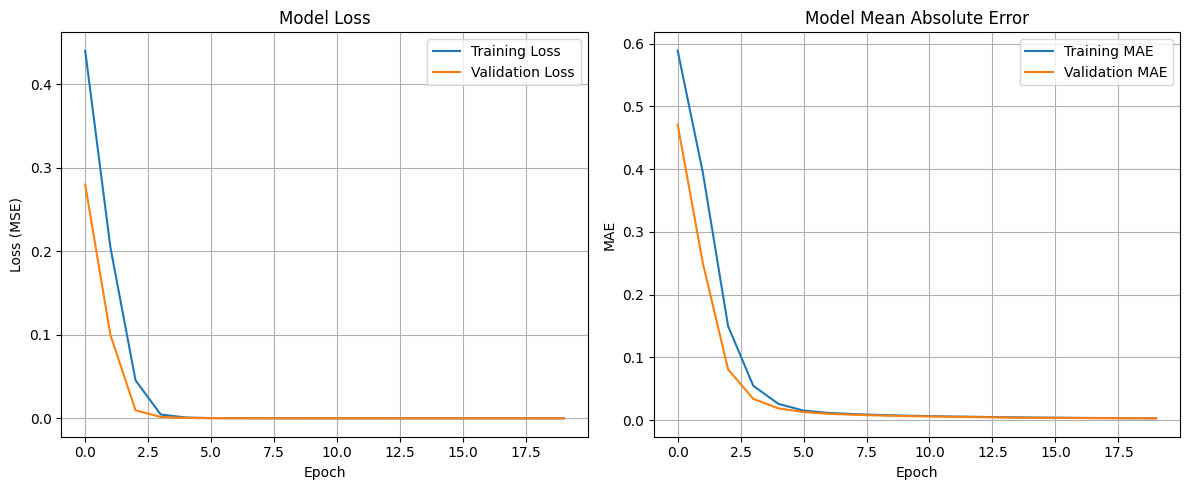

In [5]:
history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    validation_split=0.2 # Use 20% of data for validation
)

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 6. Make predictions

After training, you can use the model to make predictions on new data.

In [6]:
# Generate some new data for prediction
new_X = np.array([np.sin(i + np.arange(seq_length)) for i in np.linspace(101, 105, 5)])
new_X = new_X.reshape(5, seq_length, 1)

predictions = model.predict(new_X)

print("\nExample Predictions:")
for i in range(len(new_X)):
    print(f"Input sequence (last 3 elements): {new_X[i, -3:, 0].flatten()} -> Predicted next value: {predictions[i][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

Example Predictions:
Input sequence (last 3 elements): [ 0.92681851  0.81674261 -0.04424268] -> Predicted next value: -0.8636
Input sequence (last 3 elements): [ 0.81674261 -0.04424268 -0.86455145] -> Predicted next value: -0.8892
Input sequence (last 3 elements): [-0.04424268 -0.86455145 -0.8899956 ] -> Predicted next value: -0.0964
Input sequence (last 3 elements): [-0.86455145 -0.8899956  -0.09718191] -> Predicted next value: 0.7804
Input sequence (last 3 elements): [-0.8899956  -0.09718191  0.78498039] -> Predicted next value: 0.9566


In [11]:
# Save the history of the SimpleRNN model
simple_rnn_history = history
print("SimpleRNN model's history saved.")

SimpleRNN model's history saved.


### 8. Re-compile and re-train the LSTM model

Now that the model architecture has been updated to include an LSTM layer, we need to re-compile and re-train it to observe its performance.

In [12]:
# Re-compile the LSTM model (using the previously defined LSTM architecture)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print("LSTM model re-compiled.")

LSTM model re-compiled.


In [13]:
# Re-train the LSTM model
lstm_history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    validation_split=0.2 # Use 20% of data for validation
)

print("LSTM model training complete.")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4844 - mae: 0.6270 - val_loss: 0.4482 - val_mae: 0.5998
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4317 - mae: 0.5913 - val_loss: 0.3683 - val_mae: 0.5452
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2143 - mae: 0.3929 - val_loss: 0.0709 - val_mae: 0.2342
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0191 - mae: 0.1069 - val_loss: 0.0121 - val_mae: 0.0902
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0050 - mae: 0.0564 - val_loss: 0.0027 - val_mae: 0.0418
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - mae: 0.0361 - val_loss: 0.0015 - val_mae: 0.0327
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - mae: 0.0305 - val_loss: 0.0011 - val_mae: 0.0275
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.7118e-04 - mae: 0.0263 - val_loss: 8.6573e-04 - val_mae: 0.0248
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.716

### 9. Compare performance: SimpleRNN vs. LSTM

Let's visualize the training and validation loss and MAE for both the SimpleRNN and LSTM models to compare their performance.

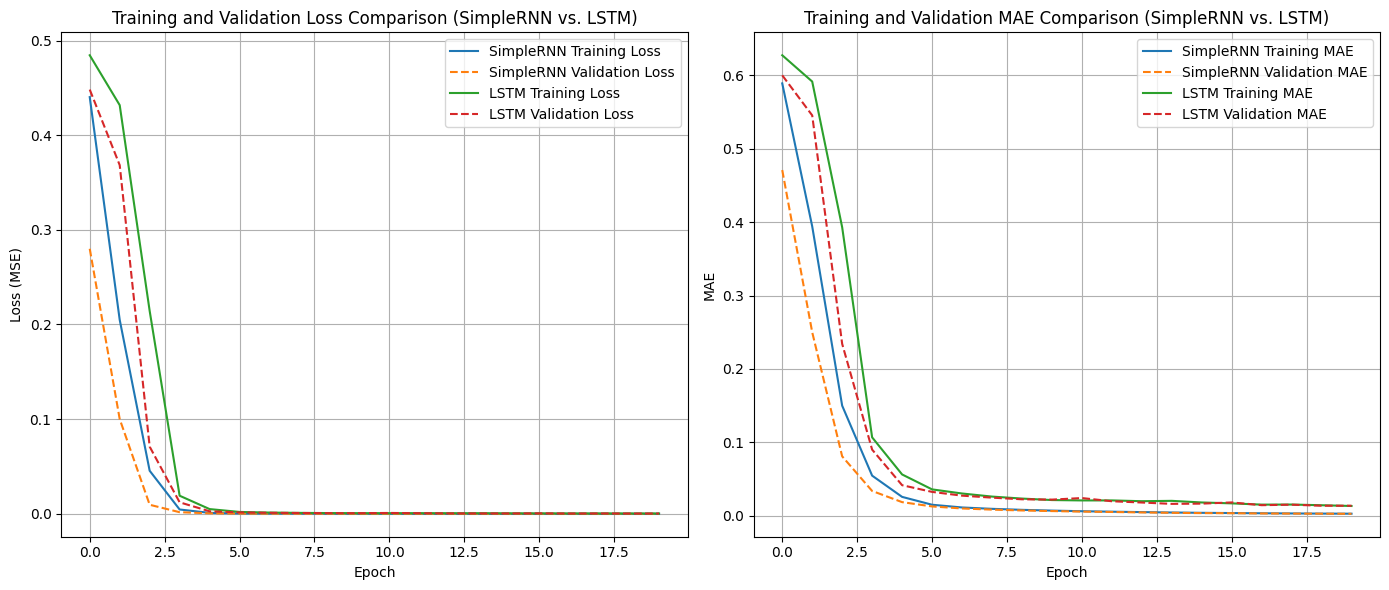

In [14]:
plt.figure(figsize=(14, 6))

# Plot Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(simple_rnn_history.history['loss'], label='SimpleRNN Training Loss')
plt.plot(simple_rnn_history.history['val_loss'], label='SimpleRNN Validation Loss', linestyle='--')
plt.plot(lstm_history.history['loss'], label='LSTM Training Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss', linestyle='--')
plt.title('Training and Validation Loss Comparison (SimpleRNN vs. LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Plot MAE Comparison
plt.subplot(1, 2, 2)
plt.plot(simple_rnn_history.history['mae'], label='SimpleRNN Training MAE')
plt.plot(simple_rnn_history.history['val_mae'], label='SimpleRNN Validation MAE', linestyle='--')
plt.plot(lstm_history.history['mae'], label='LSTM Training MAE')
plt.plot(lstm_history.history['val_mae'], label='LSTM Validation MAE', linestyle='--')
plt.title('Training and Validation MAE Comparison (SimpleRNN vs. LSTM)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()